# Machine Learning the Ising Model

In this tutorial, we will use neural networks to identify the phases of the 2D ferromagnetic Ising Model.

This exercise is adapted from the old paper [Carrasquilla & Melko 2016](https://arxiv.org/abs/1605.01735) where you can also find more complicated examples,
for example the Ising gauge theory.

As a quick reminder, we define this theory on a square Cartesian lattice of side length $L$ with toroidal topology. The Hamiltonian is
\begin{equation}
H = - \sum_{\langle i, j\rangle} s_i s_j
\end{equation}
where the summation is over nearest neighbors and the spins sitting on the lattice sites take values $s_i \in \{-1, +1\}$.
The phase transition occurs at the critical temperature
\begin{equation}
T_c = \frac{2}{\log(1+\sqrt{2})} \sim 2.2692
\end{equation}


## Generating training samples with Metropolis-Hastings

First, we need to generate training samples which we will then use to teach our neural network the phases.
We want spin configurations drawn from the equilibrium distribution at various
temperatures.
A simple way to sample such states is via the Metropolis-Hastings algorithm.
The below code implements a simple version of this algorithm.
It generates Markov chains at `Ntemp=256` linearly spaced values of temperature around the transition point.
Each chain contains `Nmeas=64` samples of a lattice with `L=32`.

You can look at the function `deltaH` to find where the physics is implemented.

In [ ]:
%%writefile ising_mh.c

#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <memory.h>
#include <math.h>

// global settings
static const uint32_t rng_seed = 13742;
static const int32_t
    L = 32, // side length of lattice
    Nequi = 2048, // number of sweeps to equilibriate
    Nmeas = 64, // number of sweeps to measure
    sweeps_per_meas = 8, // how often we sweep between measurements
    Ntemp = 256; // number of temperatures, linearly spaced, to consider
static const double
    mintemp = 1.0, // minimum temperature
    maxtemp = 3.5; // maximum temperature

// memory
static double *temps;
static int32_t *sweep_pattern; // stores random order of sites to check for flip
static int8_t *samples; // shape Ntemp * Nmeas x (LxL)

// RNG state
static uint32_t Q[4096], c = 362436;

// forward declare the RNG, implementation at the end
static void init_rand (uint32_t seed);
static inline uint32_t rand_cmwc (void);
static void fisher_yates (int32_t *x, uint32_t n);

static inline int32_t periodic (int32_t x)
{
    return (x % L + L) % L;
}

// the only physics function: it computes the change in Hamiltonian that would be induced
// if the spin at site were flipped
static inline int8_t deltaH (int8_t *lattice, int32_t site)
{
    // this is the nearest neighbours pattern
    static const int32_t offsets[4][2] = {{0, 1}, {0, -1}, {1, 0}, {-1, 0}};

    int32_t ix = site / L, iy = site % L;
    int8_t out = 0;
    for (int ii=0; ii<4; ++ii)
    {
        int32_t jx = periodic(ix + offsets[ii][0]),
                jy = periodic(iy + offsets[ii][1]),
                other_site = jx * L + jy;

        // the individual terms in Hamiltonian are -si*sj
        // If si=+, Hold=-sj, Hnew=+sj -> delta(H) = +2*sj
        // If si=-, Hold=+sj, Hnew=-sj -> delta(H) = -2*sj
        // In summary, delta(H) = 2*si*sj from this pair
        // We factorize this a bit for efficiency
        out += lattice[other_site];
    }

    return 2*out*lattice[site];
}

static inline void flip (int8_t *spin)
{
    *spin = -*spin;
}

// this is the Metropolis-Hastings iteration over the lattice
static void sweep (int8_t *lattice, double temp)
{
    for (int32_t ii=0; ii<L*L; ++ii)
    {
        int32_t site = sweep_pattern[ii];
        int8_t _deltaH = deltaH(lattice, site);
        if (_deltaH<0)
            flip(lattice+site);
        else
        {
            double logprob = - (double)(_deltaH) / temp;
            double u = (double)(rand_cmwc()) / (double)(UINT32_MAX); // U(0, 1)
            if (log(u) < logprob)
                flip(lattice+site);
        }
    }
}

int main (void)
{
    // memory allocation
    sweep_pattern = malloc(L * L * sizeof(int32_t));
    samples = malloc(Ntemp * Nmeas * L * L * sizeof(int8_t));
    temps = malloc(Ntemp * sizeof(double));

    init_rand(rng_seed);

    // initialize the sweep pattern with random permutation
    for (int ii=0; ii<L*L; ++ii) sweep_pattern[ii] = ii;
    fisher_yates(sweep_pattern, L*L);

    // initialize the temperatures
    for (int ii=0; ii<Ntemp; ++ii)
        temps[ii] = mintemp + (double)(ii) * (maxtemp-mintemp) / (double)(Ntemp-1);

    // run Metropolis-Hastings, once per temperature
    for (int ii=0; ii<Ntemp; ++ii)
    {
        int8_t *_samples = samples + ii*Nmeas*L*L; // points to samples for this one

        // perform random initialization
        for (int jj=0; jj<L*L; ++jj)
            _samples[jj] = 2 * (int32_t)(rand_cmwc() & 1U) - 1;

        // do the equilibration run
        for (int jj=0; jj<Nequi; ++jj)
            sweep(_samples, temps[ii]);

        // do the measurement run
        for (int jj=1; jj<Nmeas; ++jj)
        {
            memcpy(_samples+jj*L*L, _samples+(jj-1)*L*L, L*L*sizeof(int8_t));
            for (int kk=0; kk<sweeps_per_meas; ++kk)
                sweep(_samples+jj*L*L, temps[ii]);
        }

        if (ii) printf("\r");
        printf("%3d / %d done!", ii+1, Ntemp);
        if (ii+1 == Ntemp) printf("\n");
        fflush(stdout);
    }

    // save to disk
    {
        FILE *fp = fopen("temp.txt", "w");
        for (int ii=0; ii<Ntemp; ++ii)
            fprintf(fp, "%.8f\n", temps[ii]);
        fclose(fp);
    }

    {
        FILE *fp = fopen("samples.bin", "wb");
        fwrite(samples, sizeof(int8_t), Ntemp*Nmeas*L*L, fp);
        fclose(fp);
    }

    // clean up
    free(sweep_pattern);
    free(samples);
    free(temps);
}


// implementation of simple RNG, from https://stackoverflow.com/questions/9492581
static void init_rand(uint32_t x)
{
#define PHI 0x9e3779b9
    Q[0] = x;
    Q[1] = x + PHI;
    Q[2] = x + PHI + PHI;

    for (int ii=3; ii<4096; ii++)
        Q[ii] = Q[ii-3] ^ Q[ii-2] ^ PHI ^ ii;
#undef PHI
}

static inline uint32_t rand_cmwc(void)
{
    uint64_t t, a=18782LL;
    static uint32_t ii=4095;
    uint32_t x, r=0xfffffffe;
    ii = (ii+1) & 4095;
    t = a * Q[ii] + c;
    c = (t>>32);
    x = t+c;
    if (x<c)
    {
        x++;
        c++;
    }
    return (Q[ii] = r - x);
}

// standard random shuffle, from wikipedia
static void fisher_yates (int32_t *x, uint32_t n)
{
    for (uint32_t ii=n-1; ii>0; --ii)
    {
        uint32_t jj = rand_cmwc() % (ii+1);
        int32_t tmp = x[jj];
        x[jj] = x[ii];
        x[ii] = tmp;
    }
}

Overwriting ising_mh.c


Let's compile this program to a binary called `ising_mh`.

In [ ]:
!gcc -o ising_mh -O3 ising_mh.c -lm

Let's run the program, it should take around 20 seconds.

In [ ]:
!./ising_mh

256 / 256 done!


## Inspecting training samples

Let's now start to analyze the output.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

The `ising_mh` program has produced two files:


*   `temp.txt` contains the list of temperatures,
*   `samples.bin` is a binary file containing the sampled lattices. The contents are signed `char`s (+1, -1), with shape `Ntemp x Nmeas x L x L`.

Let's load these into memory and do some checks.

In [ ]:
T = np.loadtxt('temp.txt')
x = np.fromfile('samples.bin',dtype=np.int8).reshape(len(T),-1,32,32)

Let's look at some spin configurations:

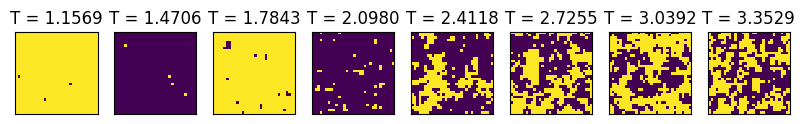

In [ ]:
fig, ax = plt.subplots(ncols=8, figsize=(10,2))
for ii, a in enumerate(ax) :
  idx = int((ii+0.5) * len(T)/len(ax))
  a.matshow(x[idx, 37], vmin=-1, vmax=1)
  a.set_title(f'T = {T[idx]:.4f}')
  a.set_xticks([])
  a.set_yticks([])

We know the order parameter for this theory very well, it is just the magnetization of the lattice:

In [ ]:
m = x.reshape(len(T),-1,32*32).mean(-1)

Let's see the transition explicitly in the order parameter:

(-1.1, 1.1)

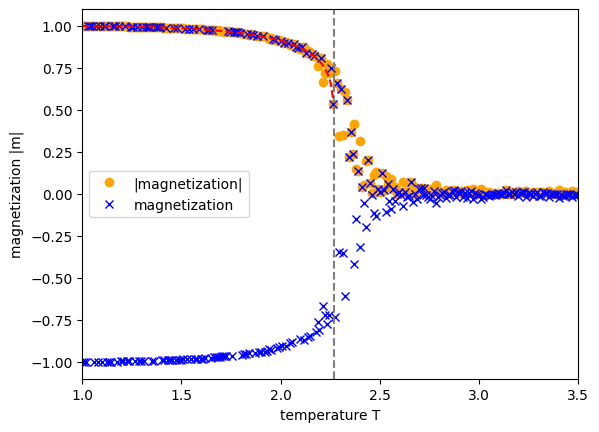

In [ ]:
Tcrit = 2/np.log(1+np.sqrt(2))
absm = np.fabs(m.mean(-1))
plt.plot(T, absm, linestyle='none', marker='o', color='orange', label='|magnetization|')
plt.plot(T, m.mean(-1), linestyle='none', marker='x', color='blue', label='magnetization')
plt.xlabel('temperature T')
plt.ylabel('magnetization |m|')
plt.axvline(Tcrit, linestyle='dashed', color='grey')

# there is a nice expression for the order parameter in the ordered phase,
# from Onsager's exact solution -- let's overplot it!
plt.plot(T[T<Tcrit], (1 - np.sinh(2/T[T<Tcrit])**(-4))**(1/8), linestyle='dashed', color='red')

plt.legend(loc='center left')
plt.xlim(np.min(T), np.max(T))
plt.ylim(-1.1, 1.1)

When training neural networks, or indeed most other machine learning models, it is customary to split the available data into three distinct sets:

* training set: this is data the model is directly trained on. Since the model sees this data and receives feedback from it, direct evaluation of performance based on the training data is usually not possible.
* validation set: usually, we perform several training passes in order to tune settings of our model. This is called hyperparameter optimization. Since the performance on the training set is unreliable, we use a held-out validation set for this.
* test set: after many iterations of hyperparameter optimization, we converge at our best model. However, due to the iterations, we may still have overfit on the validation set a little bit. This is why we report final performance on a separate test set.

A customary splitting is: 70% training, 20% validation, 10% test.
The exact split will depend on the use case.

It is usually advisable to split the data on the "outermost axis". In our case, this means to split by the temperature. The reason is that for each temperature we only have one Markov chain and the samples within a chain will be correlated. If we had samples from the same chain show up, for example, in both training and test set, the test performance could be artificially high because the model has already seen correlated examples.

Let's perform a 70/20/10 split on our data. Random numbers cluster more than many believe intuitively, so let's do it systematically.

In [ ]:
all_indices = np.arange(len(T))
test_indices = all_indices[::10]
valid_indices = all_indices[1::5]
assert not set(test_indices).intersection(set(valid_indices)) # just for safety
train_indices = sorted(list(set(all_indices).difference(set(test_indices).union(set(valid_indices)))))

print(f'Have:\n\t{len(train_indices):3d} training\n\t{len(valid_indices):3d} validation\n\t{len(test_indices):3d} test\ntemperatures (each {x.shape[1]} samples)')

# put all into one dict for easier manipulation
indices = {
    'train': train_indices,
    'valid': valid_indices,
    'test': test_indices,
}

Have:
	179 training
	 51 validation
	 26 test
temperatures (each 64 samples)


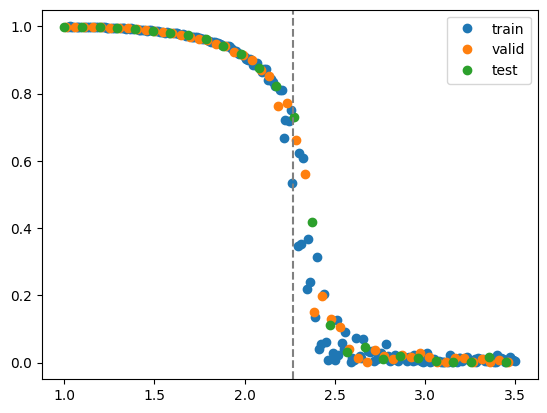

In [ ]:
for k, v in indices.items() :
  plt.plot(T[v], absm[v], linestyle='none', marker='o', label=k)
plt.axvline(Tcrit, linestyle='dashed', color='grey')
plt.legend(loc='upper right')

## Preparing training data

Now we split up our data set into separate training, validation, and testing data. We also compute the binary flag corresponding to the two phases which we will learn in the next section. Note that we transform everything into a different data format. These are PyTorch tensors, the native format for the PyTorch deep learning library. Deep learning is usually performed at single precision and the code tends to run quite a bit faster at single precision, especially on GPUs.

In [ ]:
import torch

In [ ]:
# introduce a binary label, it is:
#   1 in the disordered phase,
#   0 in the ordered phase
phase = T>Tcrit

# network inputs
x = {k: torch.from_numpy(x[v].astype('f4')) for k, v in indices.items()}

# network outputs
y = {k: torch.from_numpy(phase[v].astype('f4')) for k, v in indices.items()}

Let's transform these arrays a little bit. At the moment, the shape is `temperature x sample x L x L` for `x` and `temperature` for `y`.
It is convenient to flatten and shuffle the first two dimensions in `x` and to match the leading dimension in `y`, so that we have a proper dataset of `(x, y)` tuples.

In [ ]:
rng = torch.Generator()
rng.manual_seed(13742)

L = x['train'].shape[-1]
print(L)

for k in x :
  # repeat temperatures for each sample
  y[k] = y[k].repeat_interleave(x[k].shape[1])

  # flatten along the first two dimensions
  x[k] = x[k].reshape(-1, L, L)

  # random shuffle -- remember the training dynamics is important!
  if k == 'train' :
    idx = torch.randperm(len(y[k]), generator=rng)
    y[k] = y[k][idx]
    x[k] = x[k][idx]

32


## Defining neural network

Now we'll construct our neural net. It's just a simple Multi-Layer Perceptron (MLP).

In [ ]:
import torch.nn as nn # PyTorch neural networks class

In [ ]:
class Perceptron (nn.Module) :
    # Unless we have a more specialized unit, we inherit from nn.Module.
    # This base class performs a lot of magic under the hood to make it easy
    # for us to write neural nets.

    def __init__ (
            self,
            dim_in: int, # input dimensionality
            dim_out: int # output dimensionality
    ) :
        # usually, we need to initialize the base class first
        # The torch Module performs some magic when instance members are added
        super().__init__()
        self.l = nn.Linear(dim_in, dim_out)
        self.activation = nn.LeakyReLU()

    def forward (self, x: torch.Tensor) -> torch.Tensor :
        # torch wraps forward(...) within the __call__ method
        # and takes care of tracing gradients automatically
        return self.activation(self.l(x))

class MultiLayerPerceptron (nn.Module) :

    def __init__ (
        self,
        dim_in: int, # input dimensionality
        dim_out: int, # output dimensionality
        N_hidden: int, # number of hidden layers
        dim_hidden: int, # dimensionality of hidden layers
    ) :
        super().__init__()
        self.perceptrons = nn.Sequential(
            *[
                Perceptron(
                    dim_hidden if ii else dim_in,
                    dim_hidden
                )
                for ii in range(N_hidden)
            ]
        )

        # final fully connected output
        self.fc = nn.Linear(dim_hidden, dim_out)

    def forward (self, x: torch.Tensor) -> torch.Tensor :
        return self.fc(self.perceptrons(x))

We initialize our network:

In [ ]:
model = MultiLayerPerceptron(
    L*L, # input dimensionality: lattice size
    1, # output dimensionality: we're doing binary classification, so a single real number
    1, # number of hidden layers
    32 # dimensionality of hidden layers
)

## Training the network

Let's construct an optimizer for our model:

In [ ]:
# we'll use the Adam optimizer
from torch.optim import Adam

In [ ]:
optimizer = Adam(
    model.parameters(), # what we're optimizing
    lr = 1e-4 # learning rate
)

It is convenient to use PyTorch's inbuilt data loader for the training set:

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
batch_size = 64

dataset = TensorDataset(x['train'], y['train'])
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True, # this randomizes the sample ordering between epochs
    generator=rng # for reproducibility, it is good to set the RNG explicitly here
)

Now let's train the network. We step through the entire training set once per epoch.

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['step', 'indices']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


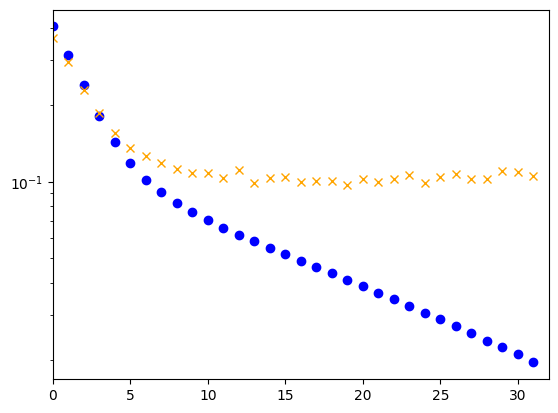

In [ ]:
Nepochs = 32

fig, ax = plt.subplots()
ax.set_xlim(0, Nepochs)
ax.set_yscale('log')

# use binary cross entropy loss (2-class classification problem)
# since our model output is on the real line, we need to add the sigmoid
# thankfully, PyTorch has a pre-built function for this
loss_function = nn.BCEWithLogitsLoss()

for epoch in range(Nepochs) :
  model.train() # this sets the model into the "training" state
  train_losses = []
  for step, (_x, _y) in enumerate(dataloader) :
    optimizer.zero_grad() # very important! Otherwise gradients get accumulated
    _ypred = model(_x.view(*_x.shape[:-2], L*L)).squeeze()
    loss = loss_function(_ypred, _y) # order important!
    loss.backward() # computes the gradients through backpropagation
    optimizer.step() # updates the network parameters according to Adam rule
    train_losses.append(loss.item())
  train_loss = sum(train_losses) / len(train_losses)

  # now we check performance on the validation set
  model.eval() # sets model into the "evaluation" state
  _ypred = model(x['valid'].view(*x['valid'].shape[:-2], L*L)).squeeze()
  validation_loss = loss_function(_ypred, y['valid']).item()

  ax.plot([epoch, ], [train_loss, ], linestyle='none', marker='o', color='blue')
  ax.plot([epoch, ], [validation_loss, ], linestyle='none', marker='x', color='orange')
  fig.show() # for some reason, I can't get it to update continuously...

## Hyperparameter optimization

We are now able to train the network!

### Exercise 1

Implement early stopping, such that the training gets halted once the validation loss increases due to overfitting.

### Exercise 2

Tune the hyperparameters of the model. Like the number of hidden neurons, the number of hidden layers, the learning rate, etc.

Can you make the validation loss smaller?

### Exercise 3

Implement some form of regularization. For example, the Adam optimizer supports L2 regularization natively. Does it help to improve the validation loss?

## Model evaluation

With your final best model at hand, let's see how it performs.

### Exercise 4

Compute the predictions on the test set.
Then compare to the test labels to construct a binary array containing 1 where the prediction was correct and 0 where the prediction was wrong.
Using this array, compute the prediction accuracy as a function of temperature
(remember that we didn't shuffle the test data, so there is a direct correspondence with `T[indices["test"]]`).

Plot the accuracy as a function of temperature. Are there any interesting trends?

## Finding the transition in an unsupervised way

Let's pretend we didn't know about the transition in the Ising model, or how many phases there are.

Just looking at samples of lattices, it would be nice to figure out the qualitative structure of our data.

We can use a nonparametric method called tSNE to perform clustering on the data.

In [ ]:
from sklearn.manifold import TSNE

T = np.loadtxt('temp.txt')
x = np.fromfile('samples.bin',dtype=np.int8).reshape(len(T),-1,32,32)

# we reduce the data amount a bit so TSNE runs faster
smaller_L = 16
x = x.reshape(-1, 32, 32)[..., :smaller_L][..., :smaller_L, :]

proj = TSNE(
    n_components=2,
    max_iter=600,
    verbose=5
).fit_transform(
    x.astype('f4').reshape(-1, smaller_L * smaller_L)
)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.003s...
[t-SNE] Computed neighbors for 16384 samples in 7.900s...
[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384
[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sam

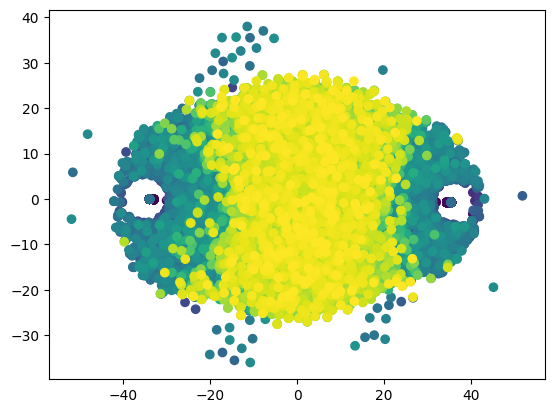

In [ ]:
plt.scatter(*proj.T, c=T.repeat(64))

### Exercise 5

Interpret the output from TSNE. Can you identify what's going on?

### Exercise 6

Look at some of the parameters in TSNE and see if you can improve the clarity of the visualization.